<a href="https://colab.research.google.com/github/boopatt/BookshelfProject/blob/main/digit_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div
     style="padding: 20px;
            color: white;
            font-size: 250%;
            text-align: center;
            display: fill;
            border-radius: 5px;
            background-color: #023c66;
            overflow: hidden;
            font-weight: 700;
            border: 5px solid #F28C28;"
     >
    Digit Classification (MNIST) Using Feed-Forward Neural Networks
</div>

The MNIST database (Modified National Institute of Standards and Technology database) is a large database of handwritten digits that is commonly used for training various image processing systems.

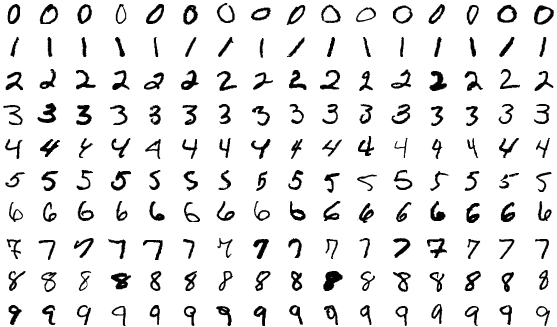

<div style="color:white;display:fill;
            background-color:#3bb2d6;font-size:200%;">
    <p style="padding: 4px;color:white;"><b>Read the Data</b></p>
</div>

In [ ]:
from tensorflow.keras.datasets import mnist
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


<div style="color:white;display:fill;
            background-color:#3bb2d6;font-size:200%;">
    <p style="padding: 4px;color:white;"><b>Visualizing Digits</b></p>
</div>

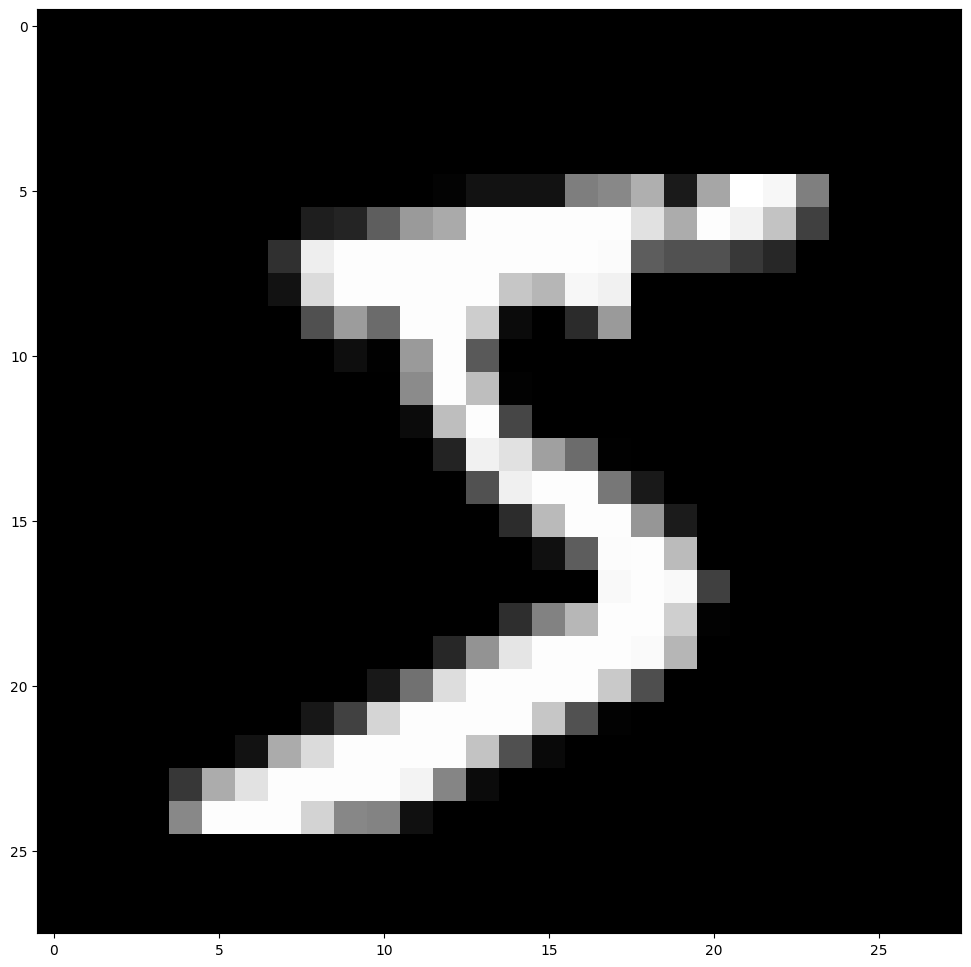

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,12))
plt.imshow(X_train[0], cmap=plt.get_cmap('gray'))

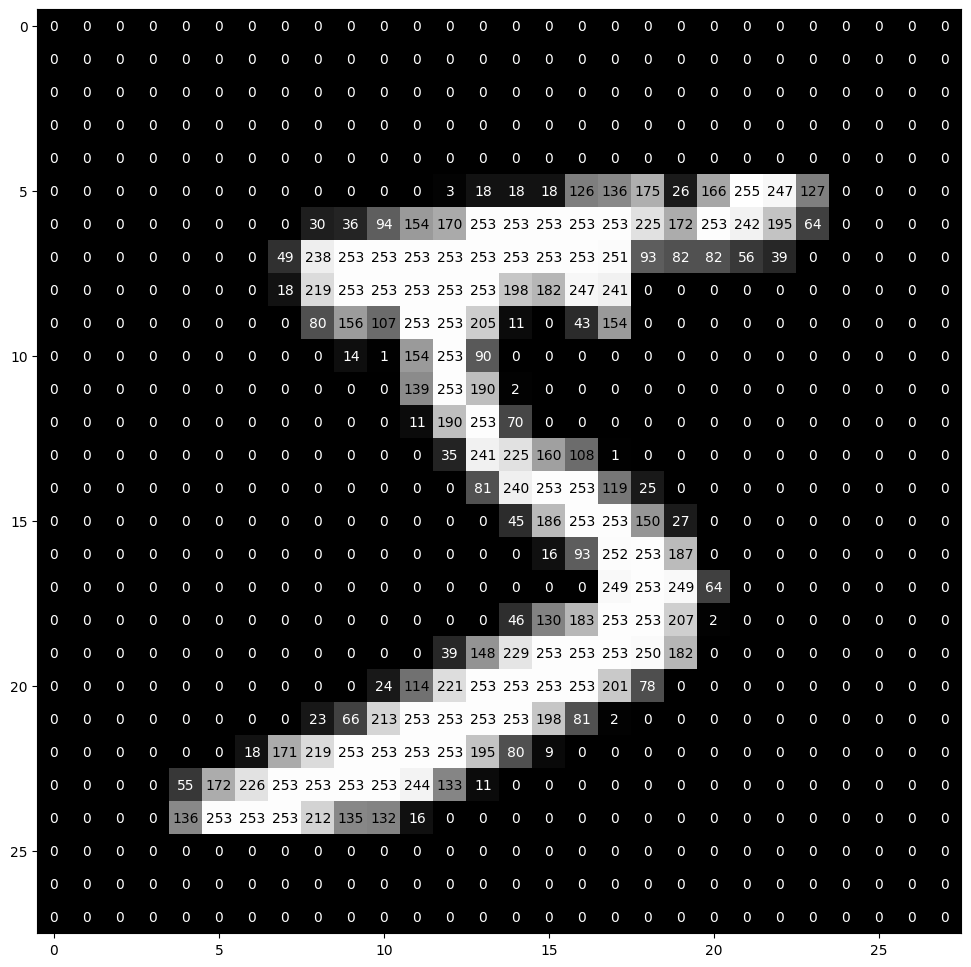

In [ ]:
## you can use other functions to better visualize the digits

def visualize_input(img, ax):
    ax.imshow(img, cmap='gray')
    width, height = img.shape
    thresh = img.max()/2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(round(img[x][y],2)), xy=(y,x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if img[x][y]<thresh else 'black')

fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
visualize_input(X_train[0].reshape(28,28), ax)

<div style="color:white;display:fill;
            background-color:#3bb2d6;font-size:200%;">
    <p style="padding: 4px;color:white;"><b>Feature Scaling</b></p>
</div>

Pixel intensities go from 0 to 255, so it is generally accepted to scale images by dividing by 255. This would scale the raw pixel intensities to the range [0, 1]

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

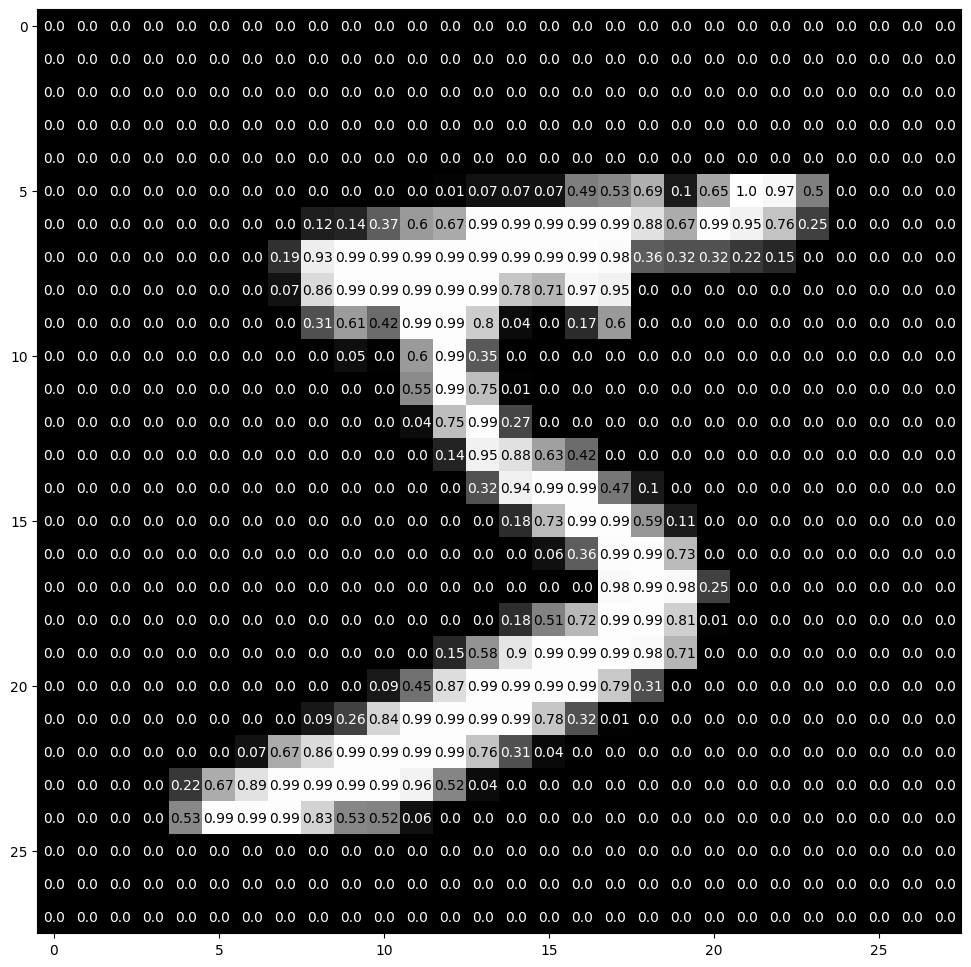

In [ ]:
fig = plt.figure(figsize = (12,12))
ax = fig.add_subplot(111)
visualize_input(X_train[0].reshape(28,28), ax)

<div style="color:white;display:fill;
            background-color:#3bb2d6;font-size:200%;">
    <p style="padding: 4px;color:white;"><b>1) Build the MLP Model</b></p>
</div>

Train a Multi-Layer Perceptron (feed-forward architecture) with the following characteristics:

* 1st hidden layer with 250 neurons and ReLu activation (add 10% dropout).
* 2nd hidden layer with 100 neurons and ReLu activation (add 10% dropout).

Remember the cost function should be:

* Categorical cross entropy

and the activation for the output layer must be the `softmax` activation.

Train for at least 10 epochs with a batch size of 128.

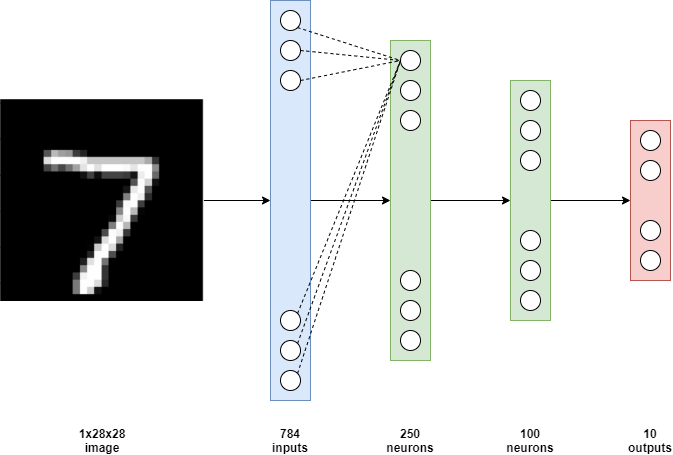

In [ ]:
from numpy import mod
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.utils import to_categorical

tf.keras.backend.clear_session() # Clear Keras session to prevent lingering name scope issues

# Reshape X_train and X_test to flatten the images
X_train_reshaped = X_train.reshape(X_train.shape[0], 784)#2D pixel structure into a 1D vector
X_test_reshaped = X_test.reshape(X_test.shape[0], 784)#28x28 image and lays all its rows of pixels end-to-end to create a single row of 784 pixels.

# One-hot encode the target labels
y_train_one_hot = to_categorical(y_train, num_classes=10)#due to multiclass problem
y_test_one_hot = to_categorical(y_test, num_classes=10)

model = Sequential(name="mnist_model") # Explicitly naming the model with a valid name
model.add(Input(shape=(784,)))
model.add(Dense(250, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(100, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(
    X_train_reshaped, y_train_one_hot,
    epochs=10,
    batch_size=128,
    validation_data=(X_test_reshaped, y_test_one_hot)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9096 - loss: 0.3083 - val_accuracy: 0.9620 - val_loss: 0.1284
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9632 - loss: 0.1223 - val_accuracy: 0.9730 - val_loss: 0.0882
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9731 - loss: 0.0857 - val_accuracy: 0.9734 - val_loss: 0.0883
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9787 - loss: 0.0661 - val_accuracy: 0.9781 - val_loss: 0.0705
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9806 - val_loss: 0.0627
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9855 - loss: 0.0434 - val_accuracy: 0.9796 - val_loss: 0.0653
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9885 - loss: 0.0353 - val_accuracy: 0.9790 - val_loss: 0.0725
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 

<div style="color:white;display:fill;
            background-color:#3bb2d6;font-size:200%;">
    <p style="padding: 4px;color:white;"><b>2) Evaluate the Model</b></p>
</div>

Obtain the following metrics:

* Confusion matrix
* Classification report
* Test accuracy

Discuss which are the most commonly misclassified cases.

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Predict class probabilities
y_pred_probs = model.predict(X_test_reshaped)

# Convert probabilities → class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Convert one-hot test labels → class labels
y_true = np.argmax(y_test_one_hot, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
 [[ 972    1    2    0    0    2    1    1    1    0]
 [   0 1129    0    1    0    1    2    0    2    0]
 [   1    0 1019    1    1    0    2    5    3    0]
 [   0    0    4  999    0    0    0    1    2    4]
 [   0    0    3    0  970    0    6    1    1    1]
 [   1    0    0   18    1  863    5    0    2    2]
 [   3    2    0    1    5    1  944    0    2    0]
 [   1    5    8    3    0    0    0 1003    3    5]
 [   3    1    3    5    4    5    1    3  947    2]
 [   3    4    0    4   11    4    1    3    4  975]]


##**Confusion Matrix Analysis**

The confusion matrix shows that the model is doing a very good job. Most numbers are on the diagonal, which means the model is correctly predicting almost all digits.
There are only a few mistakes, and those mistakes mostly happen between digits that look similar when handwritten. For example, the model sometimes predicts 8 instead of 2, 9 instead of 4,2 instead of 7,3 instead of 8, 5 instead of 3, and  4 instead of 9. These are the places where the model gets confused the most.
Even though these mistakes exist, the numbers are still very small compared to the total correct predictions. This means the model understands the digit patterns well, and only struggles with a few tricky cases where the handwriting looks similar.
Overall, the confusion matrix shows that the model is accurate, with only a few predictable misclassifications.


##**Misclassification Cases**

Based on all rows, the biggest confusion pairs are:
- 2 → 8 : 10 times
- 4 → 9 : 8 times
- 7 → 2 : 8 times
- 8 → 3 : 7 times
- 3 → 5 : 7 times
- 9 → 4 : 9 times
These are the digits our model struggles with the most.(I am choosing the digits pairs based on number of times of misclassification is >6. So omitted the 1-6 times appearance in my confusion matrix)


In [ ]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.99      0.98      1032
           3       0.97      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.97      0.98       892
           6       0.98      0.99      0.98       958
           7       0.99      0.98      0.98      1028
           8       0.98      0.97      0.98       974
           9       0.99      0.97      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_one_hot)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9821 - loss: 0.0652
Test Accuracy: 0.9821000099182129


###**Test Accuracy Interpretation**
The model got a test accuracy of 0.9823, which means it correctly predicted about 98.23% of the test images. Only a small number of images were classified incorrectly. This shows that the model learned the patterns in the digit images very well and works accurately on new, unseen data.

#3) Answer the following questions

**a) Why is ReLU activation used in hidden layers instead of sigmoid or tanh?**

Reason for ReLU:
Gradient is 1 for all positive values No saturation on the positive side

Gradients flow easily → fast learning

This is the number one reason ReLU dominates.

Second ReLU outputs 0 for all negative inputs. This means:

* Many neurons become inactive
* Network becomes sparse
* Sparse networks generalize better
* Training becomes more stable

**Reason for not using Sigmoid and tanh:**

Sigmoid/tanh activate every neuron all the time → dense, noisy gradients.


**b) What does dropout do, and why is it applied in this model?**

Dropout Functionality
Dropout is regularization technique that prevents a neural network from overfitting.

During training, dropout:

* randomly turns off (drops) a percentage of neurons
* typically 10%–50%
* on every forward pass
* and every batch Example with dropout rate = 0.5:
* Half of the neurons are ignored during that training step
* Their weights do not update
* Next batch → a different random half is dropped So the network is forced to learn multiple independent representations, not rely on a few strong neurons.


**c) Why is softmax activation used in the output layer?**

Softmax Functionality:
Softmax is used in the output layer because it converts the raw output scores of the network into a probability distribution over all classes. It ensures that every output value lies between 0 and 1 and that all probabilities sum to 1. This makes it suitable for multi-class classification problems such as digit recognition, where only one class is correct. Softmax also works naturally with the categorical cross-entropy loss function, making training stable and efficient. By amplifying the largest score and suppressing the others, Softmax provides a clear and interpretable prediction for the final class.
If you want, I can also rewrite the ReLU, dropout, or any other explanation in the same clean style.

**d) Why do we choose categorical cross-entropy as opposed to binary cross-entropy?**

Categorical cross-entropy
Categorical cross‑entropy is used because digit classification is a multi‑class problem with one correct class. Softmax produces a probability distribution over all classes, and categorical cross‑entropy measures how well this distribution matches the true one‑hot label. Binary cross‑entropy is only appropriate for two‑class or multi‑label problems, so it does not fit the structure of digit classification.

**e) What changes would you make to improve the model's performance?**

To Improve Model Performance
* Increase the number of neurons or add another hidden layer
* Reduce or tune the dropout rate to avoid underfitting
* Use a better optimizer like Adam or tune the learning rate
* Train for more epochs and use early stopping
* Normalize the input data properly
* Apply light data augmentation to improve generalization
* Switch to a CNN architecture for better image feature learning
